# Problem Title - Library Mode
Issue: #<issue-number>

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score,classification_report
torch.manual_seed(42)
np.random.seed(42)



## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [11]:
df=pd.read_csv('https://raw.githubusercontent.com/iiitl/Neural-Networks/main/dataset.csv')
print("Shape:",df.shape)
print("Column Names:")
print(df.columns.tolist())
print("Quality score distribution:")
print(df['quality'].value_counts().sort_index())
print("First 5 rows:")
df.head()

Shape: (6497, 13)
Column Names:
['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary']
Quality score distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64
First 5 rows:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [12]:
X = df.drop(columns=['quality', 'quality_binary']).values

y = df['quality'].values

def remap_quality(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

y = np.array([remap_quality(q) for q in y])

num_classes = 3

print(f"Number of input features: {X.shape[1]}")
print(f"Number of classes: {num_classes}")
print(f"Class distribution:")
for i, name in enumerate(['Low (3-4)', 'Medium (5-6)', 'High (7-9)']):
    print(f"  Class {i} — {name}: {np.sum(y == i)} samples")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

print(f"Training samples: {X_train_t.shape[0]}")
print(f"Test samples:     {X_test_t.shape[0]}")
print(f"Input shape:      {X_train_t.shape}")

Number of input features: 11
Number of classes: 3
Class distribution:
  Class 0 — Low (3-4): 246 samples
  Class 1 — Medium (5-6): 4974 samples
  Class 2 — High (7-9): 1277 samples
Training samples: 5197
Test samples:     1300
Input shape:      torch.Size([5197, 11])


## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [13]:
class WineQualityNet(nn.Module):
  def __init__(self,input_size,num_classes,dropout_rate=0.3):
    super(WineQualityNet,self).__init__()
    self.layer1=nn.Linear(input_size,128)
    self.layer2=nn.Linear(128,64)
    self.output_layer=nn.Linear(64,num_classes)
    self.relu=nn.ReLU()
    self.dropout=nn.Dropout(dropout_rate)
    self.batch_norm1=nn.BatchNorm1d(128)
    self.batch_norm2=nn.BatchNorm1d(64)
  def forward(self,x):
     x=self.layer1(x)
     x=self.batch_norm1(x)
     x=self.relu(x)
     x=self.dropout(x)
     x=self.layer2(x)
     x=self.batch_norm2(x)
     x=self.relu(x)
     x=self.dropout(x)
     x=self.output_layer(x)
     return x



In [14]:
#Model Creation
model=WineQualityNet(input_size=X_train_t.shape[1],num_classes=3,dropout_rate=0.3)
print(model)
print(f"Total parametrs:{sum(p.numel() for p in model.parameters()):,}")


WineQualityNet(
  (layer1): Linear(in_features=11, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Total parametrs:10,371


In [15]:
class_counts = np.bincount(y_train)
print("Samples per class in training set:")
for i, count in enumerate(class_counts):
    print(f"  Quality {i+3}: {count} samples")
total_samples = len(y_train)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights)
print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  Quality {i+3}: weight = {w:.4f}")
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
print("Loss Function:",criterion)
print("Optimizer:",optimizer)

Samples per class in training set:
  Quality 3: 197 samples
  Quality 4: 3979 samples
  Quality 5: 1021 samples
Class weights:
  Quality 3: weight = 8.7936
  Quality 4: weight = 0.4354
  Quality 5: weight = 1.6967
Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [16]:
num_epochs=100
batch_size=64
train_losses=[]
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_t,y_train_t)
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
print(f"Training for {num_epochs} epochs...")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")
for epoch in range(num_epochs):
  model.train()
  epoch_loss=0.0
  for X_batch,y_batch in train_loader:
    optimizer.zero_grad()
    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()
    epoch_loss+=loss.item()
  avg_loss=epoch_loss/len(train_loader)
  train_losses.append(avg_loss)
  if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | Loss: {avg_loss:.4f}")
print("training complete")


Training for 100 epochs...
Batch size: 64
Batches per epoch: 82
Epoch [ 10/100] | Loss: 0.4969
Epoch [ 20/100] | Loss: 0.4818
Epoch [ 30/100] | Loss: 0.4744
Epoch [ 40/100] | Loss: 0.4627
Epoch [ 50/100] | Loss: 0.4578
Epoch [ 60/100] | Loss: 0.4527
Epoch [ 70/100] | Loss: 0.4471
Epoch [ 80/100] | Loss: 0.4421
Epoch [ 90/100] | Loss: 0.4337
Epoch [100/100] | Loss: 0.4392
training complete


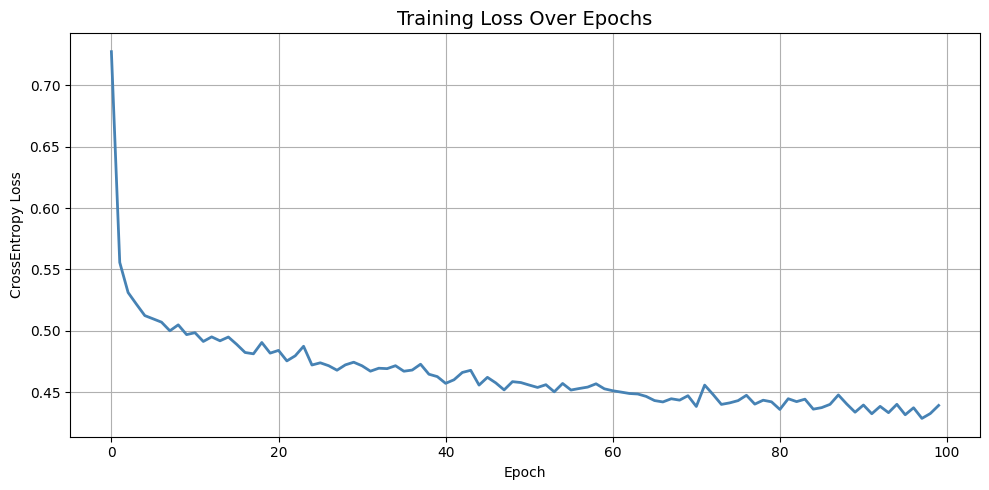

In [17]:
#plot training loss curve
plt.figure(figsize=(10,5))
plt.plot(train_losses,color='steelblue',lw=2)
plt.title("Training Loss Over Epochs",fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight')
plt.show()

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [18]:
model.eval()
with torch.no_grad():
  test_outputs = model(X_test_t)
  _, predicted = torch.max(test_outputs, dim=1)
y_pred=predicted.numpy()
y_true=y_test_t.numpy()
f1_macro=f1_score(y_true,y_pred,average='macro')
f1_weighted=f1_score(y_true,y_pred,average='weighted')
print("*=" * 25)
print("EVALUATION RESULTS")
print("*=" * 25)
print(f"Macro F1-score:    {f1_macro:.4f}")
print(f"Weighted F1-score: {f1_weighted:.4f}")
print("=*" * 25)
quality_labels=[str(i+3) for i in range(num_classes)]
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=quality_labels))


*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
EVALUATION RESULTS
*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=
Macro F1-score:    0.5058
Weighted F1-score: 0.7789
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Detailed Classification Report:
              precision    recall  f1-score   support

           3       0.60      0.06      0.11        49
           4       0.84      0.92      0.88       995
           5       0.60      0.47      0.53       256

    accuracy                           0.80      1300
   macro avg       0.68      0.48      0.51      1300
weighted avg       0.78      0.80      0.78      1300



## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
 According to me ,StandardScaler had a very huge impact.The wine dataset had a vast difference between highest mean of total_sulfur_oxide of 115.7 and loswest of chlorides which was 0.056.
 Without scaling,high valued features will be more dominant and other features will not be able to contribute anything to learning.
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
The model has decent fit for most of the classes but underfits on minority classes. The loss curve comes down at a very fast pace and flattens around epoch 80.On the test set, quality 5 and 6 achieve F1-scores of 0.65 and 0.60
respectively (good fit), while quality 3, 4, 8, and 9 score 0.00 as these classes have too few samples (6, 43, 39, 1).
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?
The Adam optimizer with lr=0.001 influenced it the most.it adapts the learning rate individually for each weight ,which was very important in case like these where input features have different scales even after being standardized.